In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pybaseball import statcast

plt.style.use('seaborn-v0_8-whitegrid')

GAME_DATE = '2026-04-29'
OPPONENT = 'BOS'
RESULT = 'W 8-1'

print(f"=== Blue Jays Game Report: {GAME_DATE} vs {OPPONENT} ({RESULT}) ===")

=== Blue Jays Game Report: 2026-04-29 vs BOS (W 8-1) ===


In [2]:
game_data = statcast(start_dt=GAME_DATE, end_dt=GAME_DATE)
jays_pitching = game_data[game_data['home_team'] == 'TOR']

# Blue Jays pitchers only
jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
# Blue Jays batters only  
jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']

print(f"Total pitches in game: {len(game_data)}")
print(f"Blue Jays pitching data: {len(jays_pitchers)} pitches")
print(f"Blue Jays batting data: {len(jays_batting)} pitches")

This is a large query, it may take a moment to complete


  0%|                                                     | 0/1 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.13/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.64it/s]

Total pitches in game: 3889
Blue Jays pitching data: 128 pitches
Blue Jays batting data: 130 pitches


In [3]:
lauer = jays_pitchers[jays_pitchers['player_name'] == 'Lauer, Eric']
print(f"Lauer total pitches: {len(lauer)}")
print(f"\n=== Pitch Mix ===")
print(lauer['pitch_type'].value_counts())
print(f"\n=== Avg Velocity by Pitch ===")
velo = lauer.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
velo = velo[velo['count'] >= 2].sort_values('mean', ascending=False)
print(velo.round(1))

Lauer total pitches: 68

=== Pitch Mix ===
pitch_type
FF    29
SL    12
FC    12
CH     8
CU     7
Name: count, dtype: int64

=== Avg Velocity by Pitch ===
            mean  count
pitch_type             
FF          90.8     29
FC          86.6     12
CH          84.1      8
SL          82.7     12
CU          75.5      7


In [4]:
print("=== Pitch Movement (inches) ===")
movement = lauer.groupby('pitch_type').agg(
    h_break=('pfx_x', lambda x: x.mean() * 12),
    v_break=('pfx_z', lambda x: x.mean() * 12),
    count=('pitch_type', 'count')
).round(1)
movement = movement[movement['count'] >= 2]
print(movement)

=== Pitch Movement (inches) ===
            h_break  v_break  count
pitch_type                         
CH              9.3      8.9      8
CU             -9.5     -9.8      7
FC             -1.3      7.5     12
FF              8.7     16.2     29
SL             -4.5      2.8     12


Chart saved!


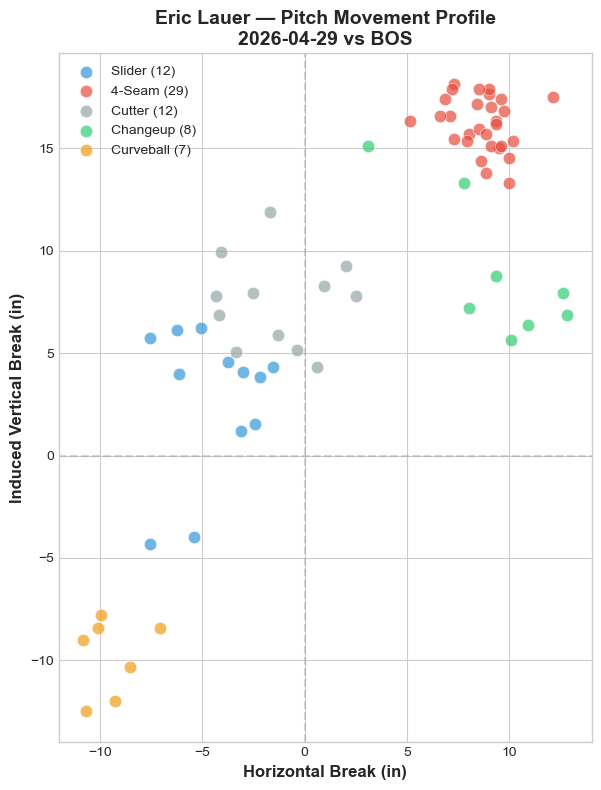

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

pitch_colors = {
    'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
    'CU': '#f39c12', 'SI': '#1abc9c', 'FC': '#95a5a6',
    'ST': '#9b59b6', 'KC': '#e67e22'
}
pitch_names = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'CU': 'Curveball', 'SI': 'Sinker', 'FC': 'Cutter',
    'ST': 'Sweeper', 'KC': 'K-Curve'
}

for pt in lauer['pitch_type'].unique():
    data = lauer[lauer['pitch_type'] == pt].dropna(subset=['pfx_x', 'pfx_z'])
    if len(data) >= 2:
        ax.scatter(data['pfx_x'] * 12, data['pfx_z'] * 12,
                   c=pitch_colors.get(pt, '#95a5a6'), s=80, alpha=0.7,
                   label=f"{pitch_names.get(pt, pt)} ({len(data)})",
                   edgecolors='white', linewidth=0.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Horizontal Break (in)', fontsize=12, fontweight='bold')
ax.set_ylabel('Induced Vertical Break (in)', fontsize=12, fontweight='bold')
ax.set_title(f'Eric Lauer — Pitch Movement Profile\n{GAME_DATE} vs {OPPONENT}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'../visualizations/movement_lauer_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [6]:
print("=== Lauer vs LHB/RHB ===")
lr_split = lauer.groupby('stand').agg(
    pitches=('pitch_type', 'count'),
    avg_velo=('release_speed', 'mean'),
    swinging_strikes=('description', lambda x: (x.isin(['swinging_strike', 'swinging_strike_blocked'])).sum())
).round(1)
lr_split['whiff_per_pitch'] = (lr_split['swinging_strikes'] / lr_split['pitches'] * 100).round(1)
print(lr_split)

print("\n=== Pitch Mix vs LHB ===")
lhb = lauer[lauer['stand'] == 'L']
if len(lhb) > 0:
    print(lhb['pitch_type'].value_counts(normalize=True).mul(100).round(1))

print("\n=== Pitch Mix vs RHB ===")
rhb = lauer[lauer['stand'] == 'R']
if len(rhb) > 0:
    print(rhb['pitch_type'].value_counts(normalize=True).mul(100).round(1))

=== Lauer vs LHB/RHB ===
       pitches  avg_velo  swinging_strikes  whiff_per_pitch
stand                                                      
L           14      87.2                 0              0.0
R           54      86.0                 4              7.4

=== Pitch Mix vs LHB ===
pitch_type
FF    50.0
SL    35.7
FC    14.3
Name: proportion, dtype: float64

=== Pitch Mix vs RHB ===
pitch_type
FF    40.7
FC    18.5
CH    14.8
SL    13.0
CU    13.0
Name: proportion, dtype: float64


Chart saved!


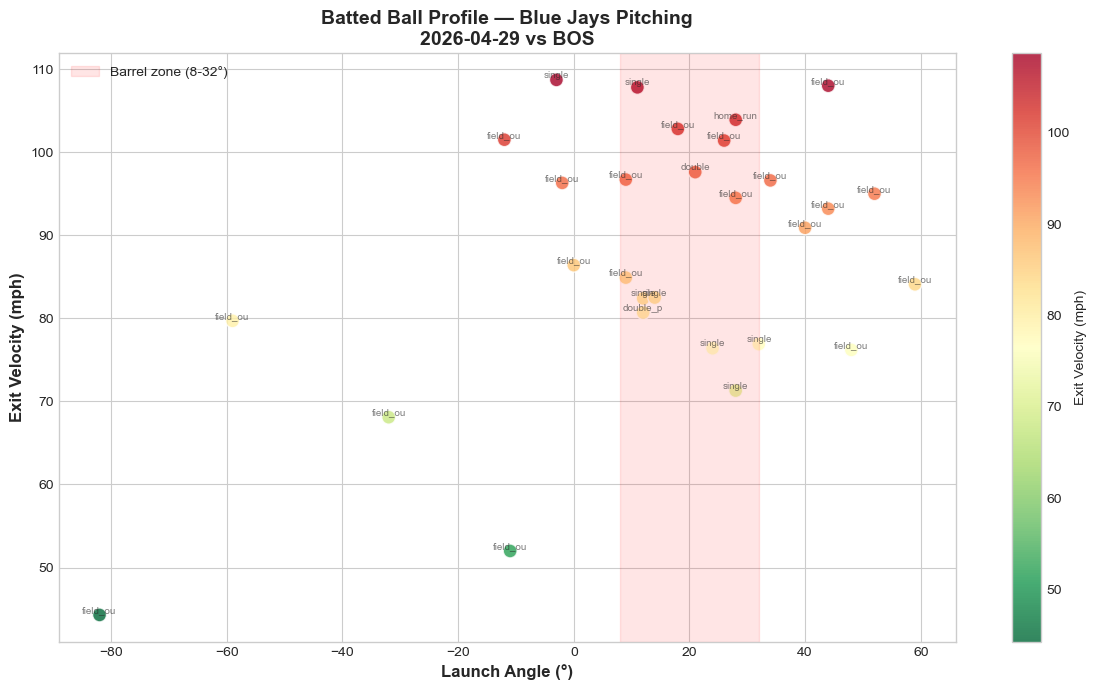


=== Batted Ball Summary ===
Total balls in play: 29
Avg exit velocity: 87.6 mph
Avg launch angle: 13.5°
Hard hit (95+ mph): 12/29


In [7]:
in_play = jays_pitchers[jays_pitchers['description'] == 'hit_into_play'].dropna(subset=['launch_speed', 'launch_angle'])

if len(in_play) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    scatter = ax.scatter(in_play['launch_angle'], in_play['launch_speed'],
                         c=in_play['launch_speed'], cmap='RdYlGn_r',
                         s=100, edgecolors='white', linewidth=1, alpha=0.8)
    
    for _, row in in_play.iterrows():
        result = row.get('events', '')
        if pd.notna(result) and result != '':
            ax.annotate(result[:8], xy=(row['launch_angle'], row['launch_speed']),
                        fontsize=7, alpha=0.6, ha='center', va='bottom')
    
    ax.axvspan(8, 32, alpha=0.1, color='red', label='Barrel zone (8-32°)')
    ax.set_xlabel('Launch Angle (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Exit Velocity (mph)', fontsize=12, fontweight='bold')
    ax.set_title(f'Batted Ball Profile — Blue Jays Pitching\n{GAME_DATE} vs {OPPONENT}',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    plt.colorbar(scatter, label='Exit Velocity (mph)')
    
    plt.tight_layout()
    plt.savefig(f'../visualizations/batted_balls_{GAME_DATE}.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()
    
    print(f"\n=== Batted Ball Summary ===")
    print(f"Total balls in play: {len(in_play)}")
    print(f"Avg exit velocity: {in_play['launch_speed'].mean():.1f} mph")
    print(f"Avg launch angle: {in_play['launch_angle'].mean():.1f}°")
    print(f"Hard hit (95+ mph): {(in_play['launch_speed'] >= 95).sum()}/{len(in_play)}")

In [8]:
print("=== Blue Jays Batting — Pitch Result Breakdown ===\n")

bos_pitching = game_data[(game_data['home_team'] == 'TOR') & (game_data['inning_topbot'] == 'Bot')]

result_map = {
    'swinging_strike': 'Whiff',
    'swinging_strike_blocked': 'Whiff',
    'called_strike': 'Called Strike',
    'foul': 'Foul',
    'foul_tip': 'Foul',
    'ball': 'Ball',
    'blocked_ball': 'Ball',
    'hit_into_play': 'In Play',
    'hit_into_play_no_out': 'In Play',
    'hit_into_play_score': 'In Play'
}

bos_pitching['result_cat'] = bos_pitching['description'].map(result_map).fillna('Other')

pitch_results = bos_pitching.groupby(['pitch_type', 'result_cat']).size().unstack(fill_value=0)
print(pitch_results)

=== Blue Jays Batting — Pitch Result Breakdown ===

result_cat  Ball  Called Strike  Foul  In Play  Other  Whiff
pitch_type                                                  
CH            14              0     4        5      2      1
CU             2              1     1        0      0      1
FC             0              0     2        1      0      1
FF            11              5     4        8      0      2
SI            14             13    13       10      0      1
SL             0              0     0        3      0      0
ST             4              3     1        3      0      0


/var/folders/sc/x7fdp9gs2b3fbn2n56ssf8f40000gn/T/ipykernel_1341/3650582173.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bos_pitching['result_cat'] = bos_pitching['description'].map(result_map).fillna('Other')


In [9]:
vlad_abs = bos_pitching[bos_pitching['batter'].isin(
    bos_pitching[bos_pitching['player_name'].str.contains('Guerrero', na=False)]['batter'].unique()
)]

if len(vlad_abs) > 0:
    print(f"=== Vladimir Guerrero Jr. — Plate Appearances ===")
    print(f"Total pitches seen: {len(vlad_abs)}")
    print(f"\nPitch types faced:")
    print(vlad_abs['pitch_type'].value_counts())
    print(f"\nResults:")
    print(vlad_abs['description'].value_counts())
    print(f"\nAvg exit velocity on contact: {vlad_abs['launch_speed'].dropna().mean():.1f} mph")

In [10]:
game_data.to_csv(f'../data/game_{GAME_DATE}.csv', index=False)
print(f"Game data saved: {len(game_data)} pitches")

Game data saved: 3889 pitches
